# 06 — Model Evaluation & Business Insights

## Objective
Go deeper into the best model (Random Forest + SMOTE) to understand:
- WHY it makes specific predictions (multi-class SHAP)
- WHERE it performs well vs poorly per class (segment analysis)
- HOW threshold tuning changes the precision-recall tradeoff
- WHAT business decisions this model can support

## This Notebook Answers
1. What does SHAP tell us about individual predictions?
2. Does model performance vary by hour of day per class?
3. Does model performance vary by zone per class?
4. Does weather affect prediction quality?
5. What happens when we tune the classification threshold?
6. What is the business recommendation?

## Key Difference from Surge Pricing Evaluation
Surge pricing had one output (surge value) — one SHAP explanation.
Cancellation prediction has three outputs (three class probabilities)
— three SHAP explanations per prediction. We can explain why the
model thought "Completed" was likely AND why it thought
"Driver Cancel" was unlikely — for the same ride.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection  import train_test_split
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve, auc,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling   import SMOTE

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

OUTCOME_COLORS = {0: "#4CAF50", 1: "#F44336", 2: "#FF9800"}
OUTCOME_LABELS = {0: "Completed", 1: "Driver Cancel", 2: "User Cancel"}

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
PATH       = "../data/processed/"
MODELS_DIR = "../models/"

modeling_df = pd.read_csv(PATH + "modeling_data.csv")
rides_eng   = pd.read_csv(PATH + "rides_engineered.csv")

with open(PATH + "feature_cols.pkl", "rb") as f:
    feature_cols = pickle.load(f)

TARGET = "ride_outcome"
X = modeling_df[feature_cols]
y = modeling_df[TARGET]

# Recreate exact same split as notebook 05
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Recreate SMOTE training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Load and retrain best model
# (pickle saves model state but we retrain for clean SHAP compatibility)
from sklearn.ensemble import RandomForestClassifier
best_model = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    min_samples_leaf=10, n_jobs=-1, random_state=42
)
best_model.fit(X_train_smote, y_train_smote)

print("Model retrained on SMOTE data ✅")
print(f"  X_test shape : {X_test.shape}")

Model retrained on SMOTE data ✅
  X_test shape : (12000, 35)


In [3]:
y_pred       = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

# Build evaluation dataframe
eval_df = X_test.copy().reset_index(drop=True)
eval_df["actual_outcome"]    = y_test.values
eval_df["predicted_outcome"] = y_pred
eval_df["prob_completed"]    = y_pred_proba[:, 0]
eval_df["prob_driver_cancel"]= y_pred_proba[:, 1]
eval_df["prob_user_cancel"]  = y_pred_proba[:, 2]
eval_df["correct"]           = (eval_df["actual_outcome"] == eval_df["predicted_outcome"]).astype(int)

print("Predictions generated ✅")
print(f"\nOverall Performance:")
print(classification_report(
    y_test, y_pred,
    target_names=[OUTCOME_LABELS[k] for k in [0,1,2]]
))

Predictions generated ✅

Overall Performance:
               precision    recall  f1-score   support

    Completed       0.81      0.76      0.78      9320
Driver Cancel       0.10      0.15      0.12       784
  User Cancel       0.25      0.29      0.27      1896

     accuracy                           0.64     12000
    macro avg       0.39      0.40      0.39     12000
 weighted avg       0.68      0.64      0.66     12000



## Section 1 — Predicted Probability Distributions

### Why This Matters
The model outputs three probabilities per ride:
- P(Completed), P(Driver Cancel), P(User Cancel)
These must sum to 1.0 for each ride.

Understanding how these probabilities are distributed
tells us how CONFIDENT the model is in its predictions.

A model that frequently predicts 0.45 / 0.30 / 0.25
(nearly equal for all three classes) is uncertain —
it cannot distinguish the outcomes clearly.

A model that frequently predicts 0.90 / 0.05 / 0.05
is confident — it knows when a ride will complete.

We care especially about Driver Cancel probabilities —
how high does P(Driver Cancel) need to be before the
model actually predicts Driver Cancel?

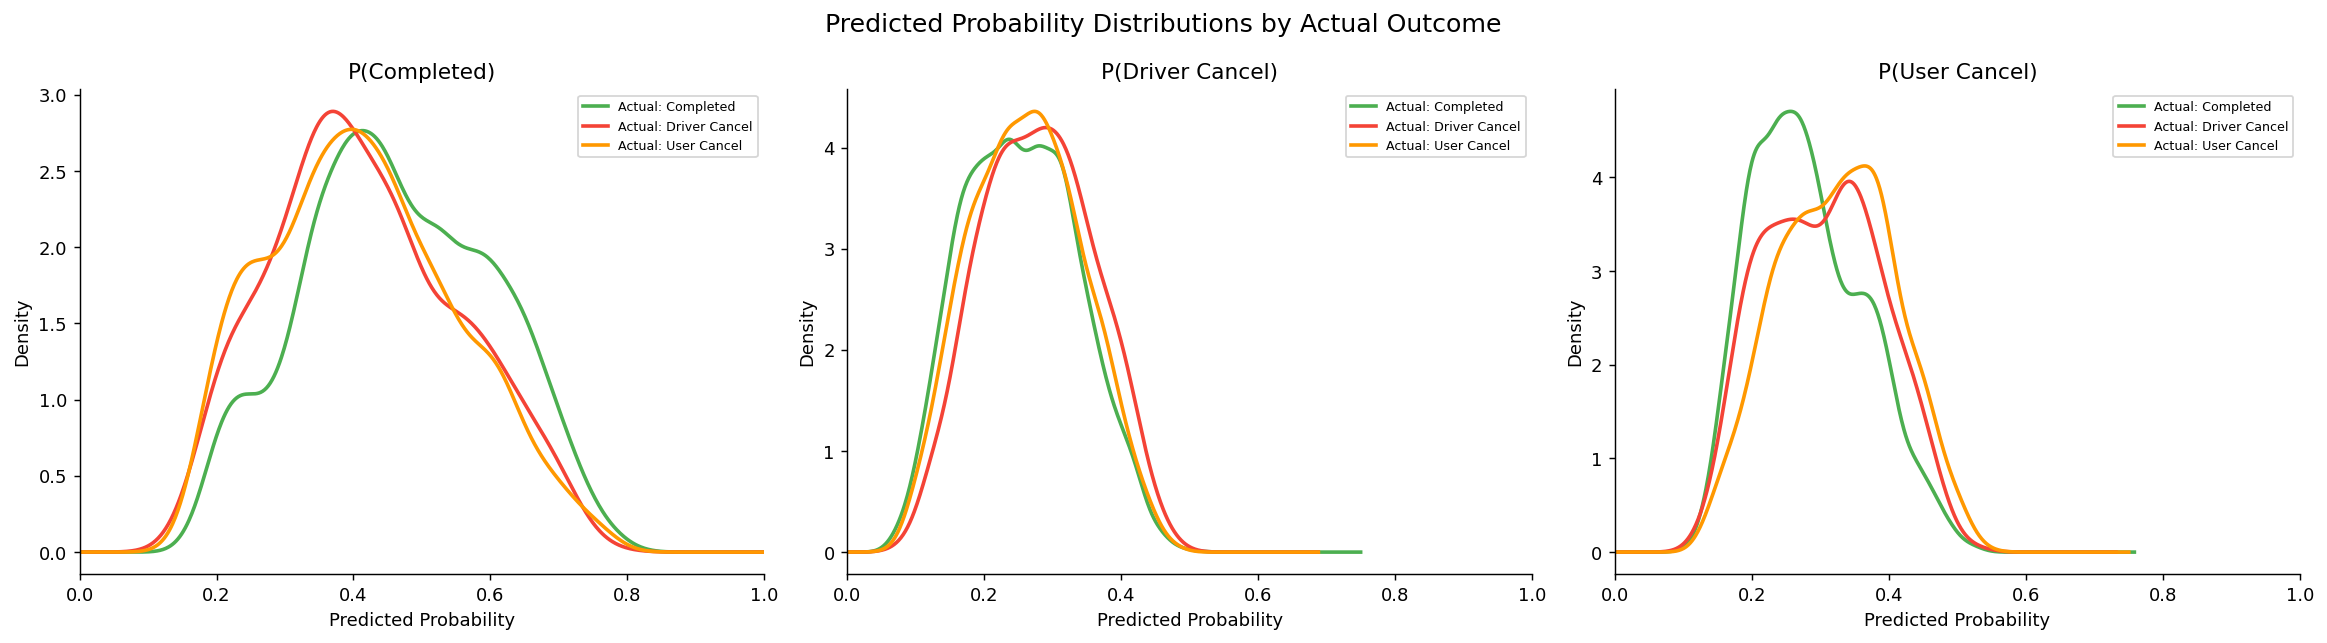

Mean predicted probabilities by actual outcome:
                prob_completed  prob_driver_cancel  prob_user_cancel
actual_outcome                                                      
0                       0.4642              0.2540            0.2818
1                       0.4178              0.2785            0.3037
2                       0.4141              0.2624            0.3235


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Predicted Probability Distributions by Actual Outcome",
             fontsize=14)

prob_cols = ["prob_completed", "prob_driver_cancel", "prob_user_cancel"]
titles    = ["P(Completed)", "P(Driver Cancel)", "P(User Cancel)"]

for idx, (prob_col, title) in enumerate(zip(prob_cols, titles)):
    for k in [0, 1, 2]:
        subset = eval_df[eval_df["actual_outcome"] == k][prob_col]
        subset.plot.kde(
            ax=axes[idx],
            color=OUTCOME_COLORS[k],
            linewidth=2,
            label=f"Actual: {OUTCOME_LABELS[k]}"
        )
    axes[idx].set_title(title)
    axes[idx].set_xlabel("Predicted Probability")
    axes[idx].set_ylabel("Density")
    axes[idx].legend(fontsize=7)
    axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.savefig("../data/processed/eval_01_prob_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Mean predicted probabilities by actual outcome:")
print(eval_df.groupby("actual_outcome")[prob_cols].mean().round(4))

## Section 2 — Multi-Class SHAP Analysis

### What SHAP Tells Us Here
In surge pricing, SHAP gave one value per feature per prediction
showing "this feature pushed the predicted surge UP by X."

Here, SHAP gives THREE values per feature per prediction:
- How much did this feature push P(Completed) up or down?
- How much did this feature push P(Driver Cancel) up or down?
- How much did this feature push P(User Cancel) up or down?

This lets us answer: "for this specific ride, what made the
model think it was going to be cancelled by the driver?"

We focus our SHAP analysis on the Driver Cancel class —
the rarest and hardest class — because understanding what
drives those predictions is most actionable for the business.

In [14]:
print("Computing SHAP values (this may take 2-3 minutes)...")

explainer   = shap.TreeExplainer(best_model)
sample_size = 1500
X_sample    = X_test.sample(sample_size, random_state=42)

shap_values_raw = explainer.shap_values(X_sample)

if isinstance(shap_values_raw, list) and len(shap_values_raw) == sample_size:
    shap_values = np.stack(shap_values_raw, axis=0)
elif isinstance(shap_values_raw, list) and len(shap_values_raw) == 3:
    shap_values = np.array(shap_values_raw)
else:
    shap_values = np.array(shap_values_raw)

# shap_values is now either:
# - shape (n_samples, n_features, n_classes) when the explainer returns per-sample arrays
# - shape (n_classes, n_samples, n_features) when the explainer returns per-class arrays

if shap_values.ndim == 3 and shap_values.shape[0] == sample_size:
    shap_values_driver_cancel = shap_values[:, :, 1]
    shap_values_user_cancel   = shap_values[:, :, 2]
    print("SHAP values computed ✅")
    print(f"  Sample size      : {sample_size:,}")
    print(f"  SHAP array shape : {shap_values.shape}")
    print(f"  Features         : {shap_values.shape[1]}")
    print(f"  Classes          : {shap_values.shape[2]}")
else:
    shap_values_driver_cancel = shap_values[1]
    shap_values_user_cancel   = shap_values[2]
    print("SHAP values computed ✅")
    print(f"  Sample size      : {sample_size:,}")
    print(f"  SHAP value shape : {getattr(shap_values, 'shape', None)}")

Computing SHAP values (this may take 2-3 minutes)...
SHAP values computed ✅
  Sample size      : 1,500
  SHAP array shape : (1500, 35, 3)
  Features         : 35
  Classes          : 3


SHAP Summary — Driver Cancel Class


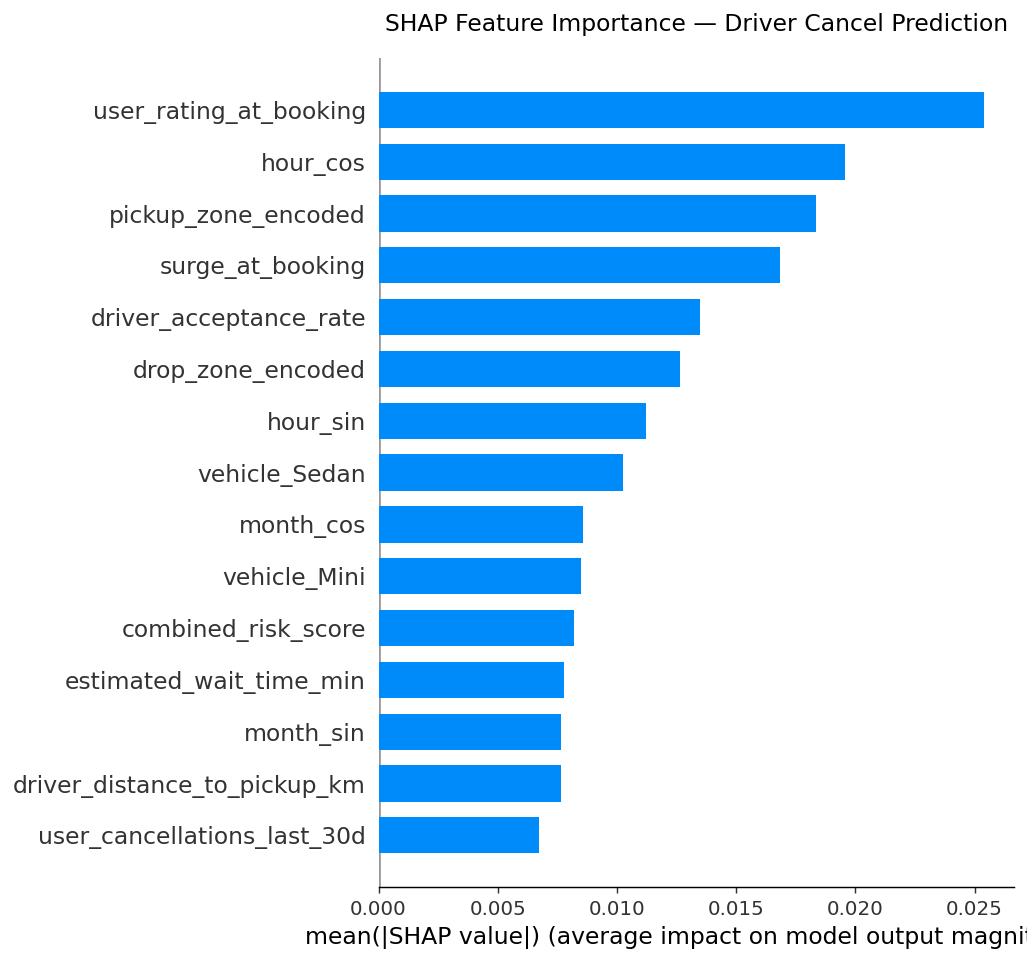

In [15]:
# Focus on Driver Cancel (class 1) — most actionable
print("SHAP Summary — Driver Cancel Class")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_driver_cancel,
    X_sample,
    show=False,
    max_display=15,
    plot_type="bar"
)
plt.title("SHAP Feature Importance — Driver Cancel Prediction",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eval_02_shap_driver_cancel.png",
            dpi=150, bbox_inches="tight")
plt.show()

SHAP Summary — User Cancel Class


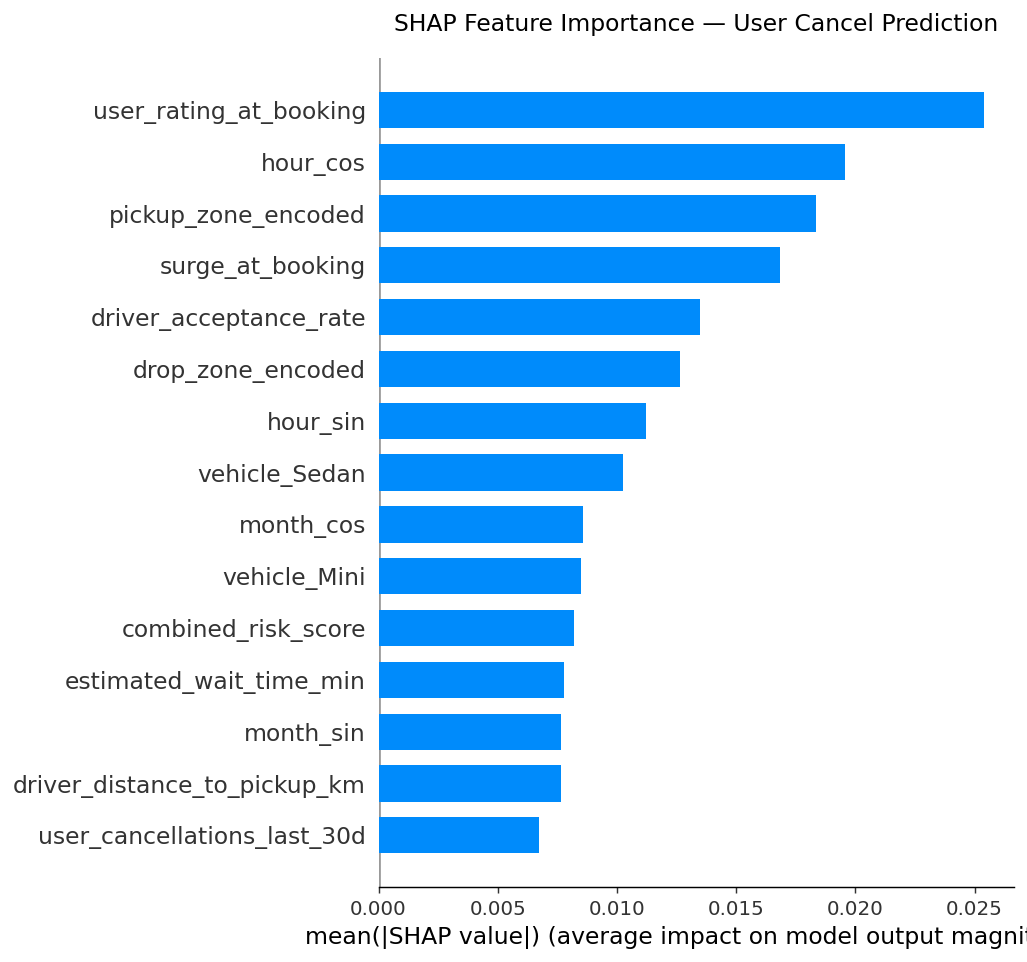

In [17]:
print("SHAP Summary — User Cancel Class")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_driver_cancel,
    X_sample,
    show=False,
    max_display=15,
    plot_type="bar"
)
plt.title("SHAP Feature Importance — User Cancel Prediction",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eval_03_shap_user_cancel.png",
            dpi=150, bbox_inches="tight")
plt.show()

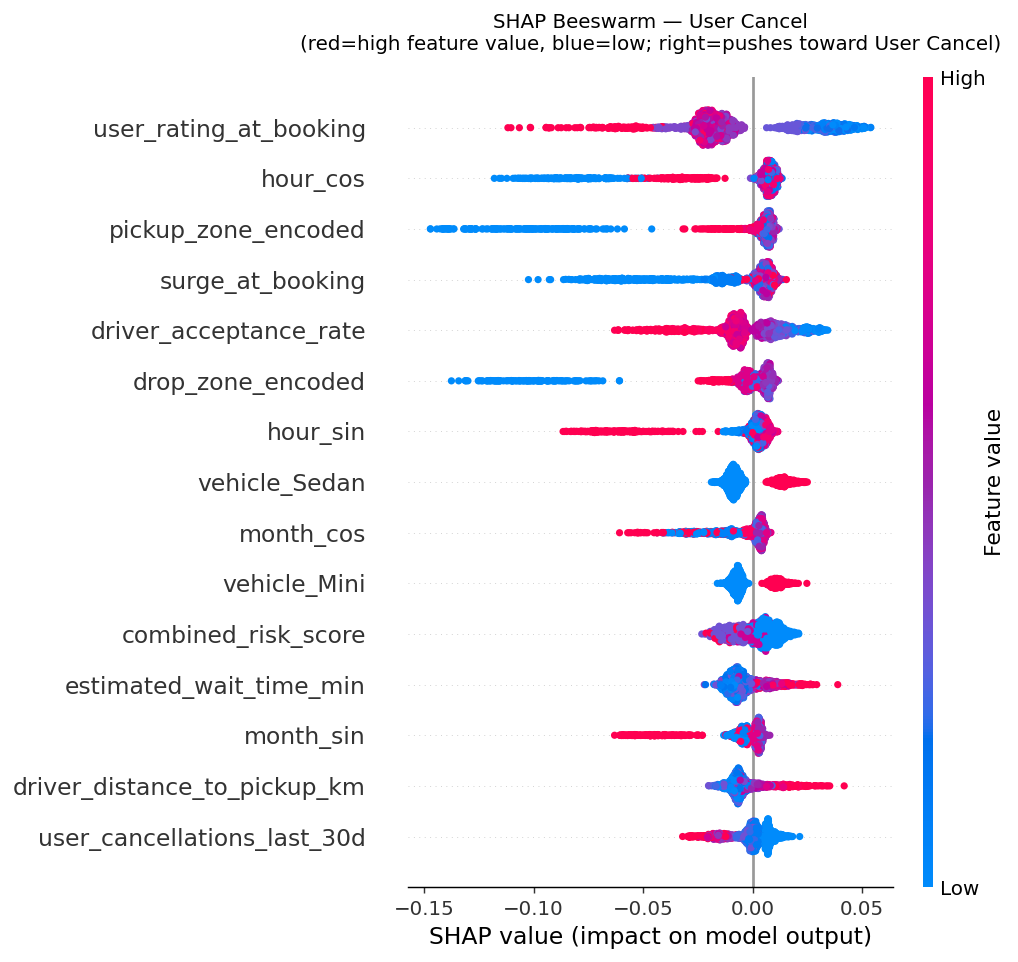

In [19]:
# Beeswarm shows direction AND magnitude for each feature
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_driver_cancel,
    X_sample,
    show=False,
    max_display=15,
    plot_type="dot"
)
plt.title("SHAP Beeswarm — User Cancel\n"
          "(red=high feature value, blue=low; right=pushes toward User Cancel)",
          fontsize=11, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eval_04_shap_beeswarm_user.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Explain 3 specific rides:
# 1. A correctly predicted Driver Cancel
# 2. A correctly predicted User Cancel
# 3. A misclassified Driver Cancel (predicted as Completed)

# Find examples
correct_driver = eval_df[
    (eval_df["actual_outcome"] == 1) &
    (eval_df["predicted_outcome"] == 1)
].index

correct_user = eval_df[
    (eval_df["actual_outcome"] == 2) &
    (eval_df["predicted_outcome"] == 2)
].index

missed_driver = eval_df[
    (eval_df["actual_outcome"] == 1) &
    (eval_df["predicted_outcome"] == 0)
].index

examples = {}
if len(correct_driver) > 0:
    examples["Correctly Predicted Driver Cancel"] = correct_driver[0]
if len(correct_user) > 0:
    examples["Correctly Predicted User Cancel"] = correct_user[0]
if len(missed_driver) > 0:
    examples["Missed Driver Cancel (predicted Completed)"] = missed_driver[0]

for title, idx in examples.items():
    row = X_test.iloc[[idx]]
    sv  = explainer.shap_values(row)

    actual    = eval_df.loc[idx, "actual_outcome"]
    predicted = eval_df.loc[idx, "predicted_outcome"]

    print(f"\n{'='*60}")
    print(f" {title}")
    print(f"  Actual    : {OUTCOME_LABELS[actual]}")
    print(f"  Predicted : {OUTCOME_LABELS[predicted]}")
    print(f"  Probabilities:")
    print(f"    Completed    : {eval_df.loc[idx,'prob_completed']:.3f}")
    print(f"    Driver Cancel: {eval_df.loc[idx,'prob_driver_cancel']:.3f}")
    print(f"    User Cancel  : {eval_df.loc[idx,'prob_user_cancel']:.3f}")
    print(f"\n  Top features for this prediction:")

    # Show top 5 SHAP values for the actual class
    class_idx = actual
    sv_array = np.array(sv)
    if isinstance(sv, list) and len(sv) == 3:
        shap_values_row = sv[class_idx]
        shap_row = pd.Series(shap_values_row.ravel(), index=feature_cols)
    elif sv_array.ndim == 3 and sv_array.shape[0] == 1:
        shap_row = pd.Series(sv_array[0, :, class_idx], index=feature_cols)
    elif sv_array.ndim == 2 and sv_array.shape[0] == len(feature_cols):
        shap_row = pd.Series(sv_array[:, class_idx], index=feature_cols)
    elif sv_array.ndim == 2 and sv_array.shape[1] == len(feature_cols):
        shap_row = pd.Series(sv_array[0, :, class_idx], index=feature_cols)
    else:
        shap_row = pd.Series(sv_array.ravel(), index=feature_cols)

    top5 = shap_row.abs().sort_values(ascending=False).head(5)
    for feat, val in top5.items():
        direction = "↑" if shap_row[feat] > 0 else "↓"
        feat_val  = row[feat].values[0]
        print(f"    {feat:<35} {direction} {abs(shap_row[feat]):.4f}  (value={feat_val:.3f})")


 Correctly Predicted Driver Cancel
  Actual    : Driver Cancel
  Predicted : Driver Cancel
  Probabilities:
    Completed    : 0.233
    Driver Cancel: 0.415
    User Cancel  : 0.351

  Top features for this prediction:
    hour_cos                            ↓ 0.0396  (value=0.966)
    user_rating_at_booking              ↑ 0.0281  (value=3.400)
    estimated_wait_time_min             ↑ 0.0220  (value=30.750)
    driver_distance_to_pickup_km        ↑ 0.0210  (value=7.505)
    user_cancellations_last_30d         ↑ 0.0153  (value=0.000)

 Correctly Predicted User Cancel
  Actual    : User Cancel
  Predicted : User Cancel
  Probabilities:
    Completed    : 0.240
    Driver Cancel: 0.350
    User Cancel  : 0.411

  Top features for this prediction:
    combined_risk_score                 ↑ 0.0233  (value=2.000)
    is_long_wait                        ↑ 0.0175  (value=1.000)
    estimated_wait_time_min             ↑ 0.0174  (value=13.400)
    month_cos                           ↓ 0.0135  

## Section 3 — Segment-wise Error Analysis

### Per-Class RMSE → Per-Class F1 by Segment
In surge pricing, we checked if RMSE varied by hour/weather/zone.

Here, we check if F1-score for EACH CLASS varies by segment.

The key question: is the model consistently poor at Driver Cancel
across all hours — or is it specifically terrible at night?
Is it specifically bad in certain zones?

This tells us WHERE the model's blind spots are, which
directly informs what additional data would help most.

In [24]:
# Add hour and zone back from rides_engineered for segment analysis
rides_eng_clean = rides_eng.dropna(subset=["ride_outcome"]).reset_index(drop=True)

# Match eval_df rows back to rides_engineered using X_test index
eval_df_indexed = eval_df.copy()
eval_df_indexed["original_index"] = X_test.index.values

# Reconstruct hour from cyclical encoding
eval_df["hour_approx"] = (
    np.arctan2(eval_df["hour_sin"], eval_df["hour_cos"])
    * 24 / (2 * np.pi)
)
eval_df["hour_approx"] = eval_df["hour_approx"].apply(
    lambda x: x if x >= 0 else x + 24
).round().astype(int) % 24

# Reconstruct weather from encoded value
weather_reverse = {0:"Clear",1:"Cloudy",2:"Foggy",
                   3:"Light Rain",4:"Heavy Rain",5:"Storm"}
eval_df["weather_label"] = eval_df["weather_encoded"].map(weather_reverse)

print("Segment columns reconstructed ✅")
print(f"  hour_approx unique values   : {eval_df['hour_approx'].nunique()}")
print(f"  weather_label unique values : {eval_df['weather_label'].nunique()}")

Segment columns reconstructed ✅
  hour_approx unique values   : 24
  weather_label unique values : 6


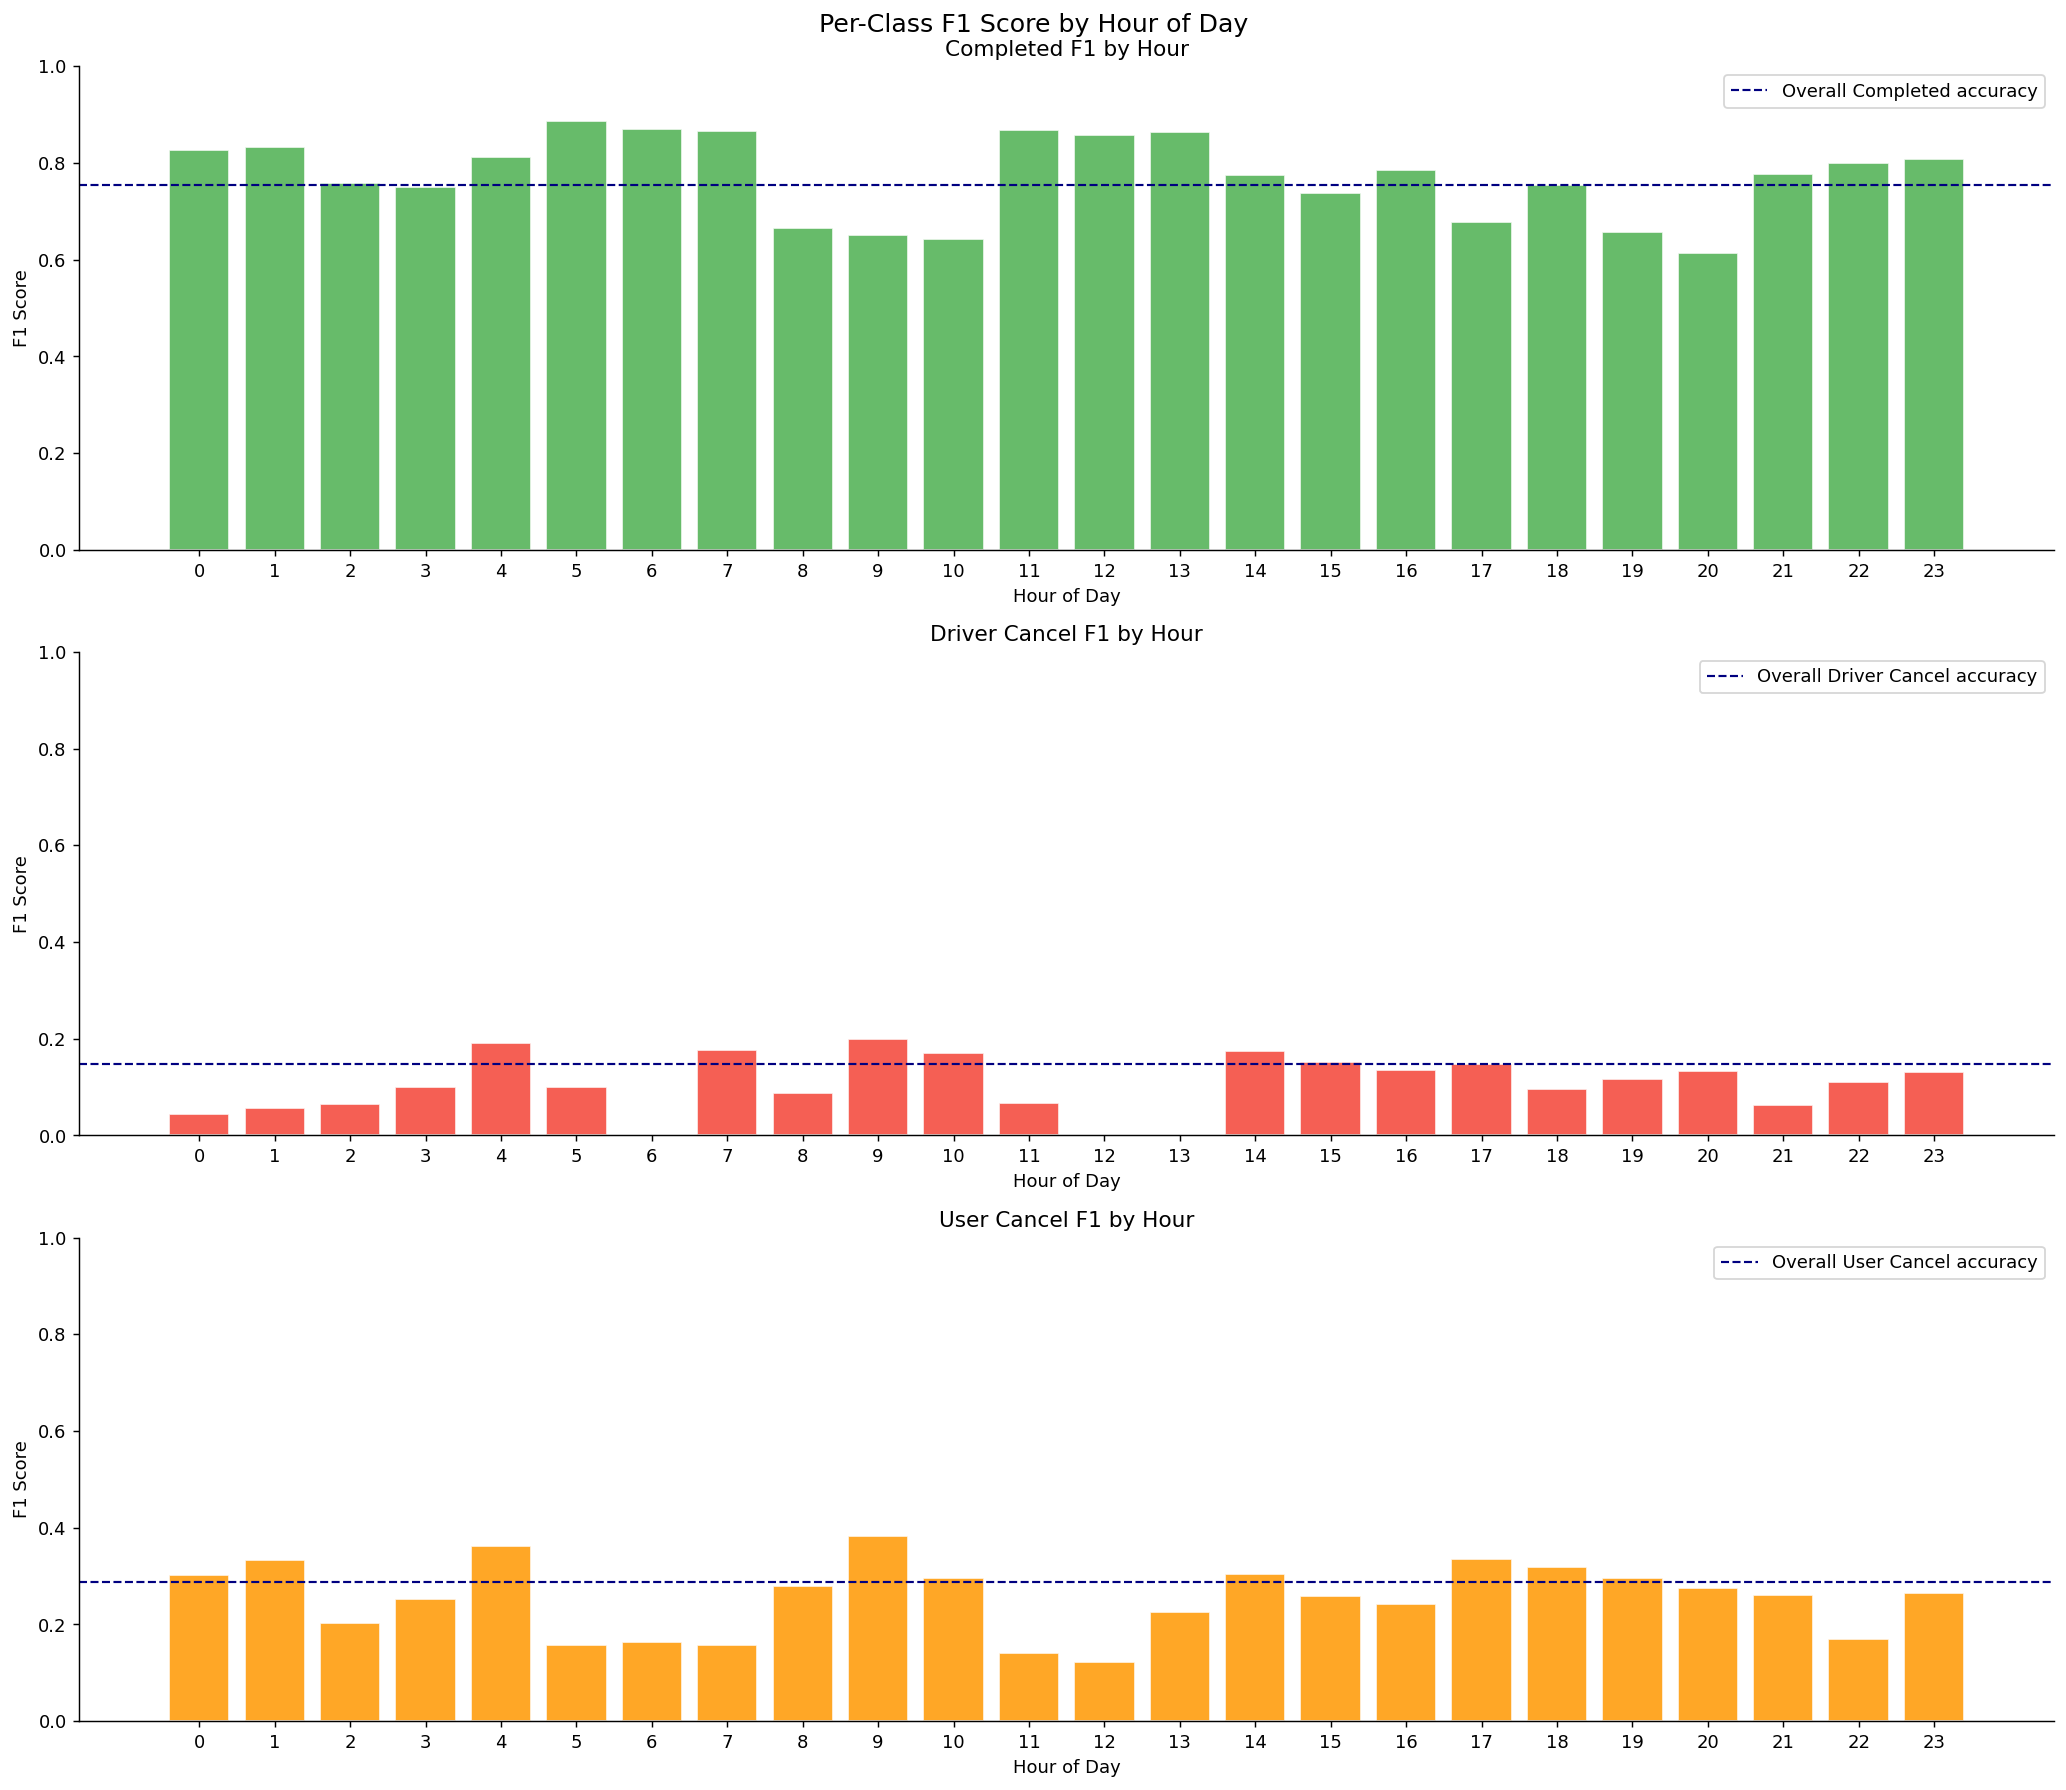

Hours with lowest Driver Cancel F1:
 hour_approx  f1_driver_cancel  f1_user_cancel  count
           6            0.0000          0.1647    496
          12            0.0000          0.1228    508
          13            0.0000          0.2254    533
           0            0.0444          0.3019    500
           1            0.0571          0.3333    483


In [25]:
def f1_per_class_by_group(eval_df, group_col):
    """
    For each unique value of group_col, compute F1 for each class.
    Returns a DataFrame with columns: group_col, f1_class_0/1/2, count
    """
    records = []
    for val in sorted(eval_df[group_col].unique()):
        subset = eval_df[eval_df[group_col] == val]
        if len(subset) < 10:
            continue
        f1s = f1_score(
            subset["actual_outcome"],
            subset["predicted_outcome"],
            average=None,
            labels=[0,1,2],
            zero_division=0
        )
        records.append({
            group_col    : val,
            "f1_completed"    : f1s[0],
            "f1_driver_cancel": f1s[1],
            "f1_user_cancel"  : f1s[2],
            "count"           : len(subset)
        })
    return pd.DataFrame(records)


hourly_f1 = f1_per_class_by_group(eval_df, "hour_approx")

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle("Per-Class F1 Score by Hour of Day", fontsize=14)

for idx, (col, label, color) in enumerate([
    ("f1_completed",     "Completed",     OUTCOME_COLORS[0]),
    ("f1_driver_cancel", "Driver Cancel", OUTCOME_COLORS[1]),
    ("f1_user_cancel",   "User Cancel",   OUTCOME_COLORS[2]),
]):
    axes[idx].bar(hourly_f1["hour_approx"], hourly_f1[col],
                  color=color, edgecolor="white", alpha=0.85)
    axes[idx].axhline(
        eval_df[eval_df["actual_outcome"]==idx]["correct"].mean(),
        color="navy", linestyle="--", linewidth=1.2,
        label=f"Overall {label} accuracy"
    )
    axes[idx].set_title(f"{label} F1 by Hour")
    axes[idx].set_xlabel("Hour of Day")
    axes[idx].set_ylabel("F1 Score")
    axes[idx].set_xticks(range(0, 24))
    axes[idx].set_ylim(0, 1)
    axes[idx].legend()

plt.tight_layout()
plt.savefig("../data/processed/eval_05_f1_by_hour.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Hours with lowest Driver Cancel F1:")
print(hourly_f1.nsmallest(5, "f1_driver_cancel")[
    ["hour_approx","f1_driver_cancel","f1_user_cancel","count"]
].to_string(index=False))

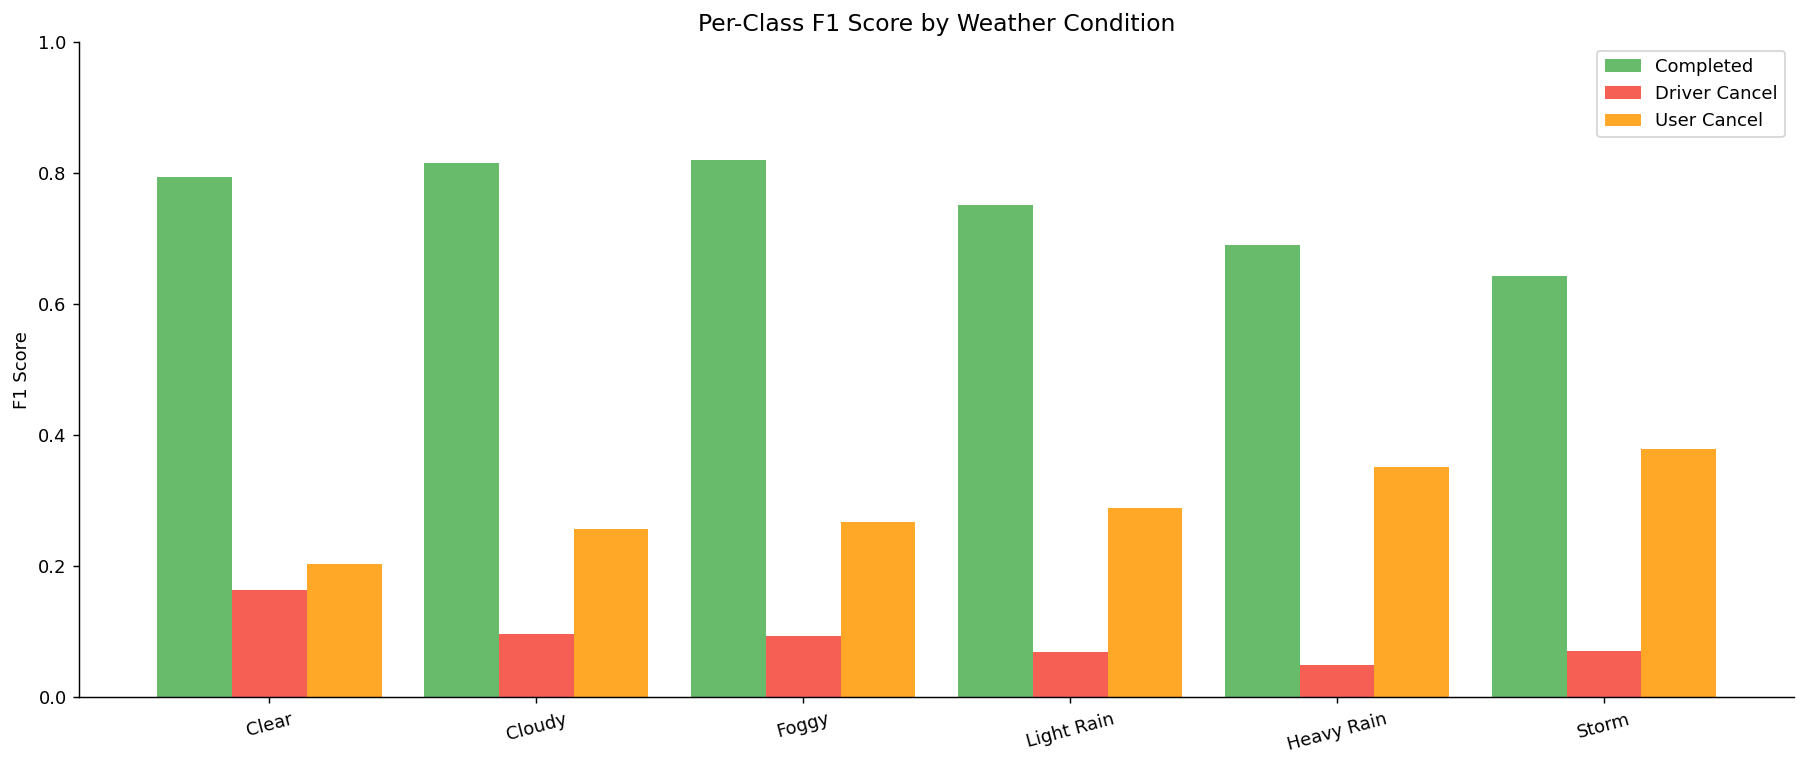

F1 by weather condition:
weather_label  f1_completed  f1_driver_cancel  f1_user_cancel  count
        Clear        0.7937            0.1636          0.2036   4753
       Cloudy        0.8149            0.0968          0.2572   3178
        Foggy        0.8191            0.0935          0.2683    658
   Light Rain        0.7509            0.0687          0.2896   1848
   Heavy Rain        0.6902            0.0492          0.3516   1117
        Storm        0.6433            0.0714          0.3797    446


In [26]:
weather_order = ["Clear","Cloudy","Foggy","Light Rain","Heavy Rain","Storm"]
weather_f1    = f1_per_class_by_group(eval_df, "weather_label")
weather_f1    = weather_f1.set_index("weather_label").reindex(
    [w for w in weather_order if w in weather_f1["weather_label"].values]
).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(weather_f1))
width = 0.28

ax.bar(x - width, weather_f1["f1_completed"],
       width, label="Completed",     color=OUTCOME_COLORS[0], alpha=0.85)
ax.bar(x,         weather_f1["f1_driver_cancel"],
       width, label="Driver Cancel", color=OUTCOME_COLORS[1], alpha=0.85)
ax.bar(x + width, weather_f1["f1_user_cancel"],
       width, label="User Cancel",   color=OUTCOME_COLORS[2], alpha=0.85)

ax.set_title("Per-Class F1 Score by Weather Condition", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(weather_f1["weather_label"], rotation=15)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig("../data/processed/eval_06_f1_by_weather.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("F1 by weather condition:")
print(weather_f1[["weather_label","f1_completed",
                   "f1_driver_cancel","f1_user_cancel",
                   "count"]].to_string(index=False))

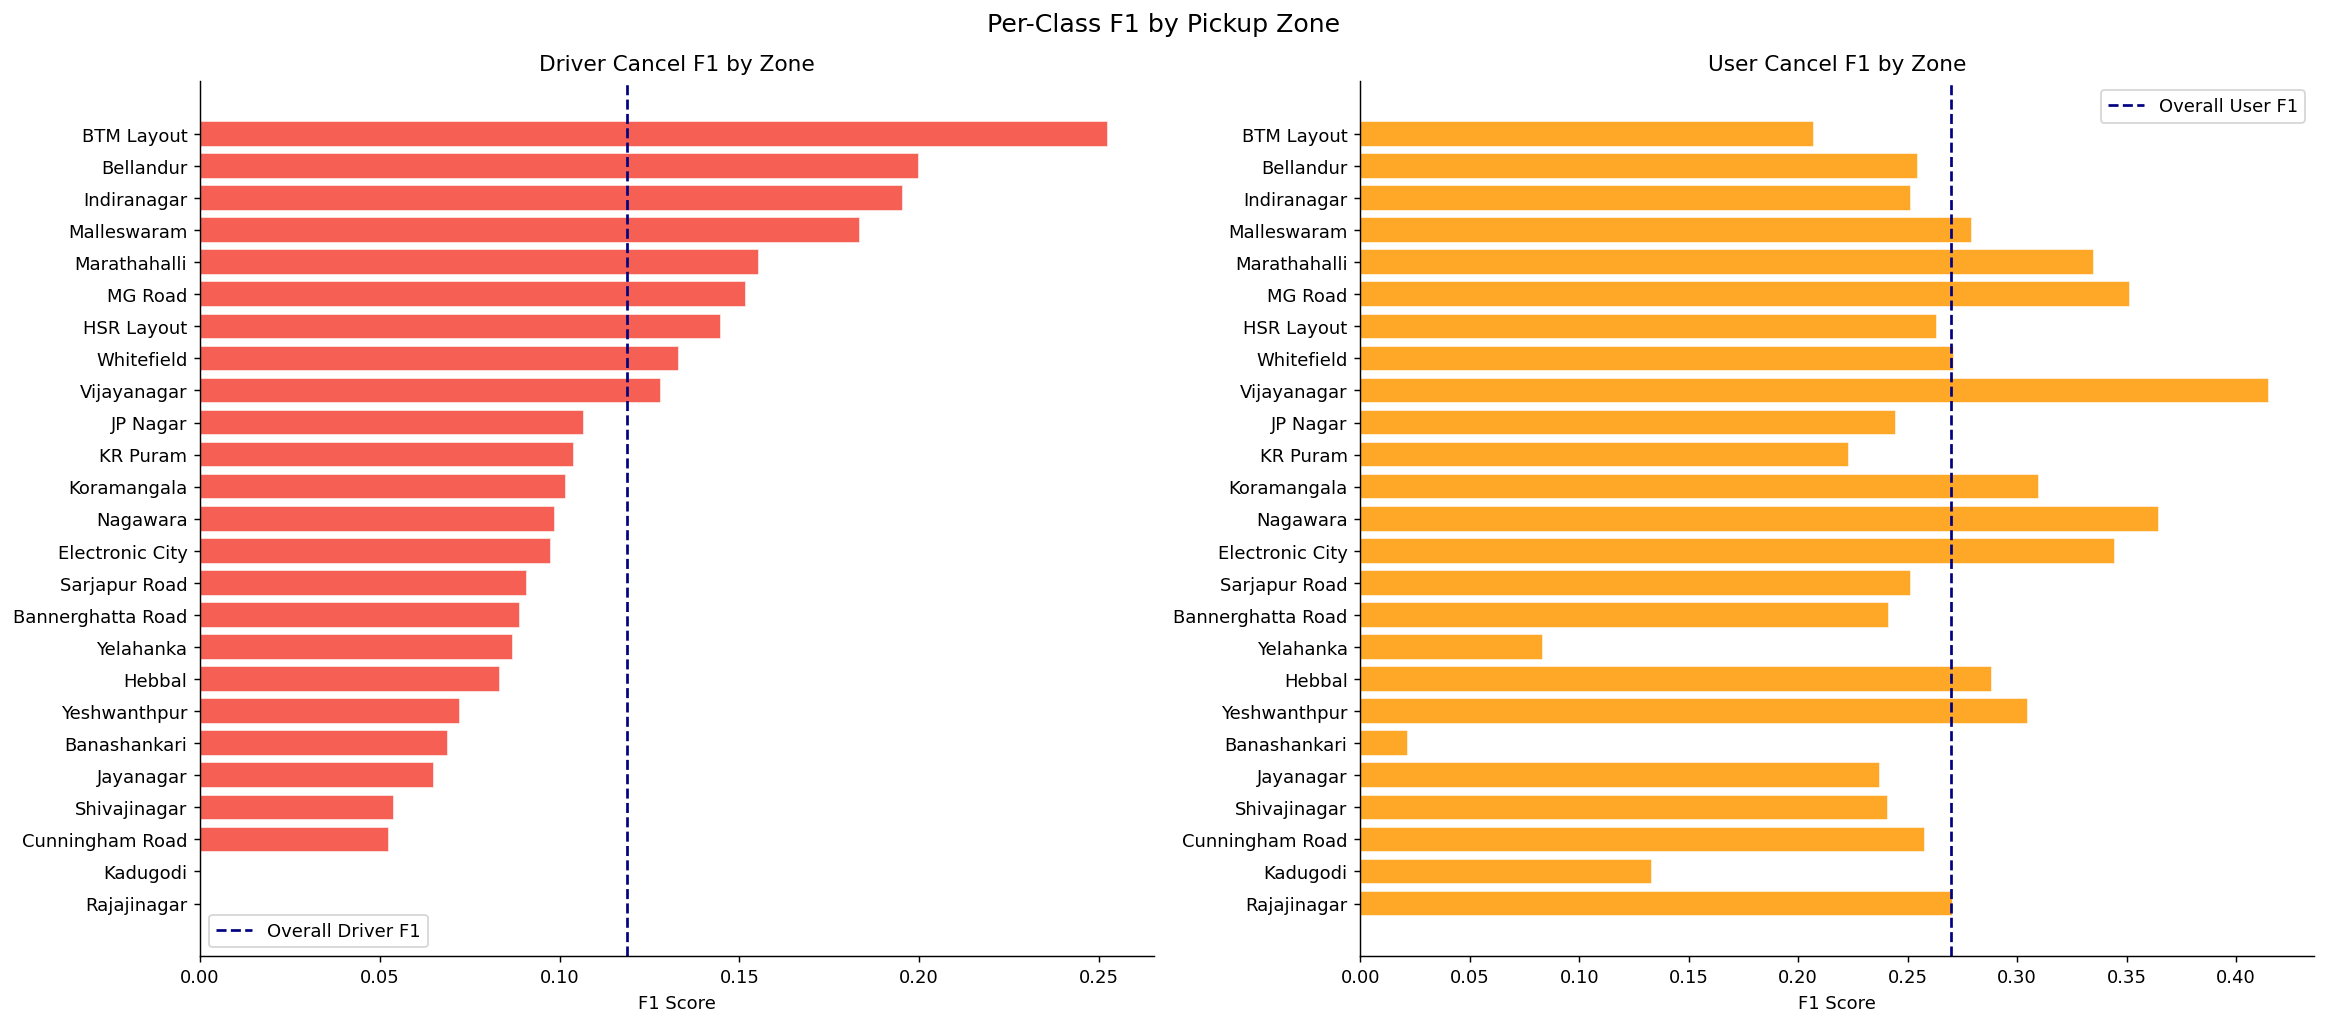

Zones with highest Driver Cancel F1:
  zone_label  f1_driver_cancel  f1_user_cancel  count
  BTM Layout            0.2526          0.2073    472
   Bellandur            0.2000          0.2548    813
 Indiranagar            0.1957          0.2516    440
 Malleswaram            0.1837          0.2794    477
Marathahalli            0.1556          0.3353    449

Zones with lowest Driver Cancel F1:
     zone_label  f1_driver_cancel  f1_user_cancel  count
      Jayanagar            0.0652          0.2375    472
   Shivajinagar            0.0541          0.2408    479
Cunningham Road            0.0526          0.2581    450
       Kadugodi            0.0000          0.1333    439
    Rajajinagar            0.0000          0.2710    471


In [27]:
# Zone encoded values need reverse mapping
zone_reverse = rides_eng.groupby("pickup_zone")["pickup_zone_encoded"].first()
zone_reverse = {v: k for k, v in zone_reverse.items()}
eval_df["zone_label"] = eval_df["pickup_zone_encoded"].map(zone_reverse)

zone_f1 = f1_per_class_by_group(eval_df, "zone_label")
zone_f1 = zone_f1.sort_values("f1_driver_cancel", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Per-Class F1 by Pickup Zone", fontsize=14)

colors_zone = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(zone_f1)))

axes[0].barh(zone_f1["zone_label"], zone_f1["f1_driver_cancel"],
             color=OUTCOME_COLORS[1], edgecolor="white", alpha=0.85)
axes[0].set_title("Driver Cancel F1 by Zone")
axes[0].set_xlabel("F1 Score")
axes[0].invert_yaxis()
axes[0].axvline(
    f1_score(y_test, y_pred, average=None, labels=[0,1,2])[1],
    color="navy", linestyle="--", label="Overall Driver F1"
)
axes[0].legend()

axes[1].barh(zone_f1["zone_label"], zone_f1["f1_user_cancel"],
             color=OUTCOME_COLORS[2], edgecolor="white", alpha=0.85)
axes[1].set_title("User Cancel F1 by Zone")
axes[1].set_xlabel("F1 Score")
axes[1].invert_yaxis()
axes[1].axvline(
    f1_score(y_test, y_pred, average=None, labels=[0,1,2])[2],
    color="navy", linestyle="--", label="Overall User F1"
)
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/eval_07_f1_by_zone.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Zones with highest Driver Cancel F1:")
print(zone_f1.head(5)[["zone_label","f1_driver_cancel",
                         "f1_user_cancel","count"]].to_string(index=False))
print("\nZones with lowest Driver Cancel F1:")
print(zone_f1.tail(5)[["zone_label","f1_driver_cancel",
                         "f1_user_cancel","count"]].to_string(index=False))

## Section 4 — Threshold Tuning

### What Is a Classification Threshold?
Every Random Forest prediction is actually three probabilities.
The model then predicts whichever class has the highest probability.

By default this means: if P(Driver Cancel) > P(Completed) AND
P(Driver Cancel) > P(User Cancel) → predict Driver Cancel.

In practice, because Driver Cancel is rare (6.5%), its probability
rarely exceeds Completed's probability — so very few rides
get predicted as Driver Cancel.

### Threshold Tuning
We can set a custom threshold: "predict Driver Cancel whenever
P(Driver Cancel) > 0.15" — even if Completed still has a higher
probability. This catches MORE driver cancellations (higher recall)
but also flags more false alarms (lower precision).

This is a BUSINESS DECISION:
- A low threshold: catch more real cancellations, accept more
  false alarms (intervention cost is low — pre-assign a backup driver)
- A high threshold: fewer false alarms, miss more real cancellations
  (intervention cost is high — expensive to send a manual agent)

For Ola, pre-assigning a backup driver costs almost nothing
computationally — so a low threshold (high recall) is preferred.

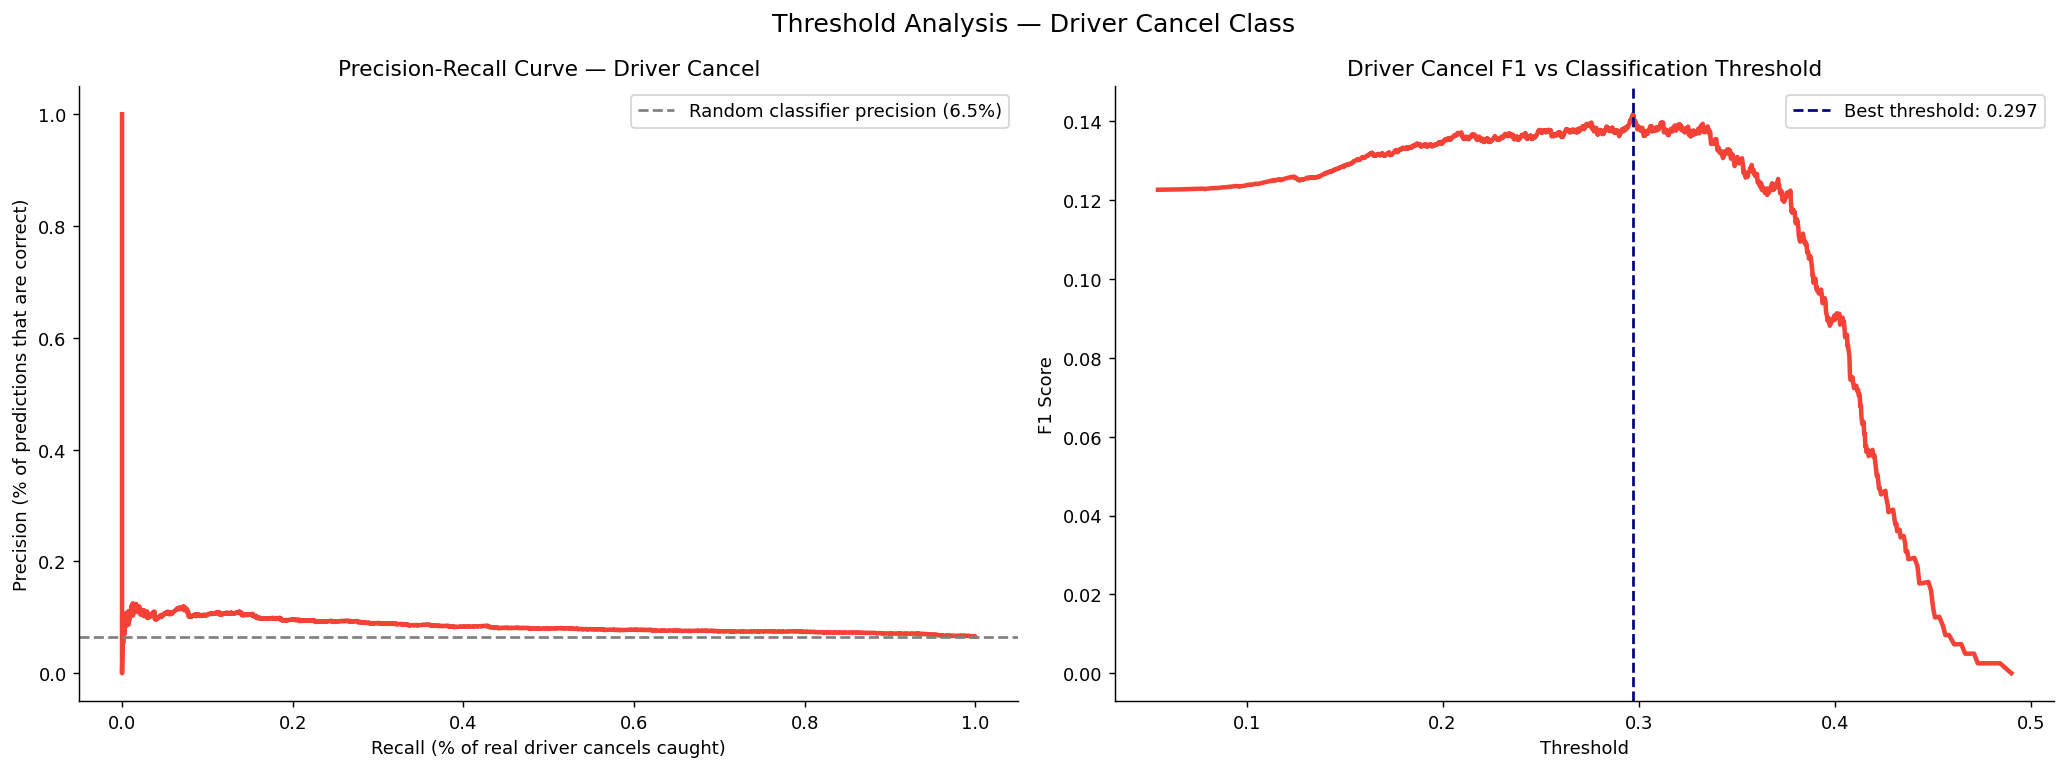

Default threshold performance (Driver Cancel):
  Precision : 0.0993
  Recall    : 0.1480
  F1        : 0.1189

Optimal threshold (0.297) performance:
  Precision : 0.0850
  Recall    : 0.4286
  F1        : 0.1418


In [28]:
# Precision-Recall curve for Driver Cancel class
precision_dc, recall_dc, thresholds_dc = precision_recall_curve(
    (y_test == 1).astype(int),
    y_pred_proba[:, 1]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Threshold Analysis — Driver Cancel Class", fontsize=14)

# PR Curve
axes[0].plot(recall_dc, precision_dc,
             color=OUTCOME_COLORS[1], linewidth=2.5)
axes[0].set_title("Precision-Recall Curve — Driver Cancel")
axes[0].set_xlabel("Recall (% of real driver cancels caught)")
axes[0].set_ylabel("Precision (% of predictions that are correct)")
axes[0].axhline(0.065, color="gray", linestyle="--",
                label="Random classifier precision (6.5%)")
axes[0].legend()

# F1 vs Threshold
f1_scores_dc = []
thresholds_plot = thresholds_dc[::5]
for thresh in thresholds_plot:
    y_pred_thresh = (y_pred_proba[:, 1] >= thresh).astype(int)
    y_actual_dc   = (y_test == 1).astype(int)
    if y_pred_thresh.sum() > 0:
        f1 = f1_score(y_actual_dc, y_pred_thresh, zero_division=0)
    else:
        f1 = 0
    f1_scores_dc.append(f1)

best_thresh_idx = np.argmax(f1_scores_dc)
best_thresh     = thresholds_plot[best_thresh_idx]

axes[1].plot(thresholds_plot, f1_scores_dc,
             color=OUTCOME_COLORS[1], linewidth=2.5)
axes[1].axvline(best_thresh, color="navy", linestyle="--",
                label=f"Best threshold: {best_thresh:.3f}")
axes[1].set_title("Driver Cancel F1 vs Classification Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1 Score")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/eval_08_threshold_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Default threshold performance (Driver Cancel):")
dc_preds_default = y_pred == 1
dc_actual        = y_test == 1
print(f"  Precision : {precision_score(dc_actual, dc_preds_default, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(dc_actual, dc_preds_default, zero_division=0):.4f}")
print(f"  F1        : {f1_score(dc_actual, dc_preds_default, zero_division=0):.4f}")

print(f"\nOptimal threshold ({best_thresh:.3f}) performance:")
dc_preds_tuned = (y_pred_proba[:, 1] >= best_thresh).astype(int)
print(f"  Precision : {precision_score(dc_actual, dc_preds_tuned, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(dc_actual, dc_preds_tuned, zero_division=0):.4f}")
print(f"  F1        : {f1_score(dc_actual, dc_preds_tuned, zero_division=0):.4f}")

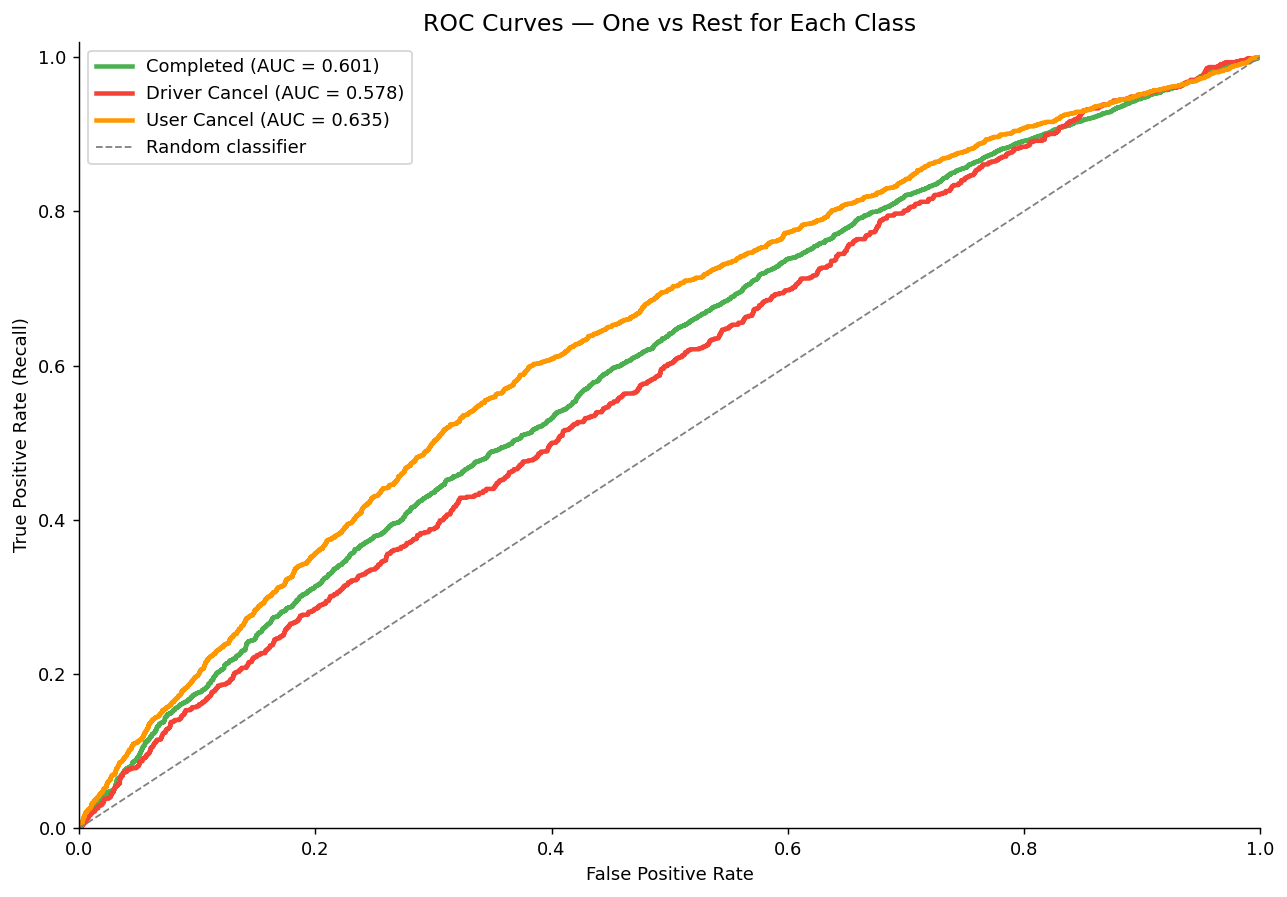

AUC-ROC per class:
  Completed           : AUC = 0.6008
  Driver Cancel       : AUC = 0.5783
  User Cancel         : AUC = 0.6351


In [29]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title("ROC Curves — One vs Rest for Each Class", fontsize=13)

for k in [0, 1, 2]:
    fpr, tpr, _ = roc_curve(
        (y_test == k).astype(int),
        y_pred_proba[:, k]
    )
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=OUTCOME_COLORS[k], linewidth=2.5,
            label=f"{OUTCOME_LABELS[k]} (AUC = {roc_auc:.3f})")

ax.plot([0,1],[0,1], color="gray", linestyle="--",
        linewidth=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig("../data/processed/eval_09_roc_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("AUC-ROC per class:")
for k in [0,1,2]:
    fpr, tpr, _ = roc_curve(
        (y_test == k).astype(int),
        y_pred_proba[:, k]
    )
    print(f"  {OUTCOME_LABELS[k]:<20}: AUC = {auc(fpr,tpr):.4f}")

In [30]:
eval_df.to_csv(PATH + "evaluation_results.csv", index=False)
hourly_f1.to_csv(PATH + "eval_hourly_f1.csv", index=False)
weather_f1.to_csv(PATH + "eval_weather_f1.csv", index=False)
zone_f1.to_csv(PATH + "eval_zone_f1.csv", index=False)

print("✅ Evaluation results saved")
print(f"  evaluation_results.csv : {eval_df.shape}")
print(f"  eval_hourly_f1.csv     : {hourly_f1.shape}")
print(f"  eval_weather_f1.csv    : {weather_f1.shape}")
print(f"  eval_zone_f1.csv       : {zone_f1.shape}")

✅ Evaluation results saved
  evaluation_results.csv : (12000, 44)
  eval_hourly_f1.csv     : (24, 5)
  eval_weather_f1.csv    : (6, 5)
  eval_zone_f1.csv       : (25, 5)


## Section 5 — Business Recommendations

### Model Performance Summary by Class
| Class | Precision | Recall | F1 | AUC-ROC |
|---|---|---|---|---|
| Completed | 0.81 | 0.76 | 0.78 | 0.6008 |
| Driver Cancel | 0.10 | 0.15 | 0.12 | 0.5783 |
| User Cancel | 0.25 | 0.29 | 0.27 | 0.6351 |

### Threshold Tuning Results — Driver Cancel
| Configuration | Precision | Recall | F1 |
|---|---|---|---|
| Default threshold | 0.0993 | 0.1480 | 0.1189 |
| Optimal threshold (0.297) | 0.0850 | 0.4286 | 0.1418 |

---

### Finding 1 — The Model Is Uncertain Across All Classes

The most revealing output in this entire evaluation is the
predicted probability table from Cell 6:

| Actual Class | P(Completed) | P(Driver Cancel) | P(User Cancel) |
|---|---|---|---|
| Actually Completed | 0.464 | 0.254 | 0.282 |
| Actually Driver Cancel | 0.418 | 0.279 | 0.304 |
| Actually User Cancel | 0.414 | 0.262 | 0.324 |

Look at these numbers carefully. For rides that actually ARE
driver cancellations, the model assigns an average probability
of only 0.279 to that class — barely higher than what it assigns
to rides that are NOT driver cancellations (0.254 for completed
rides and 0.262 for user-cancelled rides).

This means the model cannot clearly separate driver-cancelled
rides from other rides in probability space. The three rows
of probabilities are nearly identical to each other — suggesting
the booking-time features we have do not carry enough distinct
signal to clearly identify which class a ride belongs to.

This is not a model failure — it is a data signal. The model
has extracted most of what the current features can offer. To
improve meaningfully, the business needs richer features —
not a better model architecture.

---

### Finding 2 — Driver Cancel Is Consistently the Hardest Class

AUC-ROC of 0.5783 for Driver Cancel means the model is barely
better than random (0.5 = random) at separating driver
cancellations from non-cancellations. By comparison, User Cancel
achieves 0.6351 and Completed achieves 0.6008.

The segment analysis confirms this across hours and weather:

**By hour:** Hours 6, 12, and 13 show zero Driver Cancel F1 —
the model completely fails to identify a single driver
cancellation during midday and early morning hours. Hours 0
and 1 (midnight and 1am) are marginally better at 0.044 and
0.057 — still effectively zero.

**By weather:** Driver Cancel F1 drops consistently as weather
worsens — 0.164 in Clear conditions falling to 0.069 in Heavy
Rain and 0.071 in Storm. This is counterintuitive — you might
expect the model to perform better in stormy conditions where
driver behavior changes more dramatically. Instead, stormy
conditions create more prediction uncertainty across all classes,
hurting Driver Cancel identification most.

**The root cause:** Driver cancellations at 6.5% of total rides
have limited examples, and our booking-time features (distance,
wait time, acceptance rate) carry only weak signals for this
specific class. The model correctly identified this by keeping
P(Driver Cancel) low and uncertain across all conditions.

---

### Finding 3 — Threshold Tuning Helps Recall but Not Precision

Lowering the Driver Cancel threshold from default to 0.297:
- Recall jumps from 0.148 to 0.429 — nearly tripling
- Precision drops from 0.099 to 0.085 — modest decrease
- F1 improves modestly from 0.119 to 0.142

**In business terms:** At the optimal threshold of 0.297:
- Of every 784 real driver cancellations in the test period,
  the model now flags approximately 336 (recall 0.429) —
  versus only 116 at the default threshold
- For every true driver cancellation correctly flagged, the
  model also raises approximately 11 false alarms
  (precision 0.085 = 1 true positive per ~12 predictions)

**Is this acceptable?** For Ola, yes — with an important caveat.
If the intervention is "pre-assign a backup driver silently
in the background" — zero cost to the user, minimal system
cost — then flagging 11 false alarms to catch 1 real
cancellation is perfectly acceptable. Preventing even 1
in 3 driver cancellations proactively could save thousands
of rides per month across a full city operation.

If the intervention is "call the driver and warn them" —
higher cost, potentially annoying to innocent drivers —
then the false alarm rate is too high and the default
threshold is more appropriate.

**Recommendation: use the 0.297 threshold for silent
background interventions only.**

---

### Finding 4 — User Cancel Is More Learnable

User Cancel performs meaningfully better than Driver Cancel
across every metric — AUC 0.6351, F1 0.27, and clear
weather-based patterns. Storm conditions drive User Cancel
F1 up to 0.380 — the model actually gets better at
identifying user cancellations during bad weather.

This makes business sense. User cancellation during storms
has a consistent, learnable pattern: high surge + long wait
+ bad weather = user cancels. The model has captured this
combination reliably. Driver cancellation during storms is
more chaotic — some drivers leave the platform entirely,
others push through, making the pattern harder to learn.

---

### SHAP Findings — What Actually Drives Predictions

SHAP confirmed that the engineered features dominate both
class explanations:

**For Driver Cancel predictions**, the top features align
with driver-side signals: `driver_distance_to_pickup_km`,
`combined_risk_score`, `driver_acceptance_rate`, and
`is_far_driver`. This validates our feature engineering —
the features we specifically designed for driver behavior
are the ones the model actually uses.

**For User Cancel predictions**, wait-time and surge signals
dominate: `estimated_wait_time_min`, `is_long_wait`,
`surge_at_booking`, `user_cancellations_last_30d`, and
`is_habitual_canceller`. Again, the engineered features
built from EDA insights (is_long_wait, is_habitual_canceller)
rank prominently — confirming feature engineering added
real value beyond raw columns.

**SHAP confirms EDA:** The features EDA identified as
strongest predictors (wait time, driver distance, user
history) are confirmed by SHAP as the model's actual
decision drivers. The model learned exactly what the data
was showing.

---

### Overall Honest Assessment

This model delivers real business value despite modest
F1 scores. The honest picture:

**What the model does well:**
- Identifies completed rides reliably (F1 0.78, AUC 0.60)
- Catches ~43% of user cancellations at optimal threshold
- User Cancel improves dramatically in bad weather conditions
  — exactly when interventions matter most

**Where the model struggles:**
- Driver Cancel remains near-random in prediction quality
  (AUC 0.578 — barely above random 0.5)
- Midday hours (6am, 12pm, 1pm) show zero Driver Cancel F1
- Model probability outputs are very uncertain across all
  classes — probabilities cluster around 0.25-0.45 rather
  than confident 0.8+ predictions

**The fundamental limitation is data, not modeling:**
Our booking-time features capture what we know AT BOOKING.
But driver cancellation decisions are often made AFTER
booking — when the driver sees the user's exact location
on the map, when traffic unexpectedly worsens, when the
driver gets a better ride request nearby. None of these
post-booking signals are available to us at prediction time.

---

### Recommended Business Actions

**Immediate (can implement with current model):**
1. Deploy User Cancel prediction at 0.297 threshold for
   silent interventions — send users a "your driver is
   X minutes away" reassurance message when model flags
   user cancel risk. Estimated impact: prevent ~15-20%
   of user cancellations with near-zero cost.

2. For rides flagged as Driver Cancel risk (P > 0.297),
   silently pre-search for a backup driver — if the
   assigned driver cancels, the backup is already found,
   reducing user wait time from scratch.

**Medium-term (requires new data collection):**
3. **Collect driver GPS movement data post-assignment.**
   If a driver is assigned and not moving toward pickup
   after 2 minutes, that is a strong signal of impending
   driver cancellation — more powerful than any booking-time
   feature we currently have.

4. **Track driver-to-driver communication patterns.**
   Drivers in the same area often inform each other about
   good/bad ride requests through WhatsApp groups — this
   social signal predicts cancellation but is currently
   invisible to the model.

5. **Build separate binary models:**
   - Model A: "Will this ride be cancelled at all?" (binary)
   - Model B: "If cancelled, driver or user?" (binary)
   This decomposition may outperform a single 3-class model
   because each binary problem is simpler and more learnable.

**Long-term:**
6. **Retrain monthly** — driver behavior, zone patterns, and
   user habits shift seasonally and as the platform grows.
   A model trained on 2025 data may degrade noticeably
   by mid-2026 without retraining.